# Multiple Variable Linear Regression

In [67]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt

## Notation  
  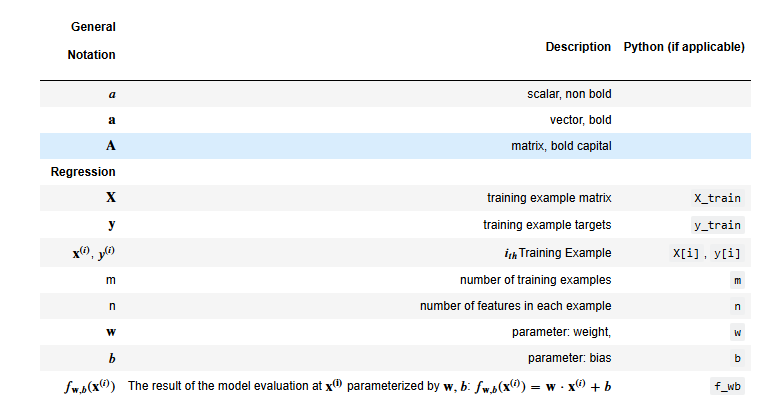

In [68]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [69]:
# data is stored in numpy array/matrix
print(f"X shape: {X_train.shape}, X type: {type(X_train)}")
print(X_train)
print(f"y shape: {y_train.shape}, y type: {type(y_train)}")
print(y_train)

X shape: (3, 4), X type: <class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y shape: (3,), y type: <class 'numpy.ndarray'>
[460 232 178]


## Parameter vector w,b

In [70]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


## Model Prediction with Multiple Variables

### Single Prediction element by element

In [71]:
def predict_single_loop(x,w,b):
    n = x.shape[0]
    p = 0
    
    for i in range(n):
        p_i = w[i] * x[i]
        p = p + p_i
    p = p + b
    return p

In [72]:
# get a row from our training data
x_vec = X_train[0]
print(f"x_vec shape: {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict_single_loop(x_vec,w_init,b_init)
print(f"f_wb shape: {f_wb.shape}, prediction: {f_wb}")
# x_vec is a NumPy 1-D vector so, the result is a scalar.

x_vec shape: (4,), x_vec value: [2104    5    1   45]
f_wb shape: (), prediction: 459.9999976194083


### Single Prediction, Vector

In [73]:
def predict(x,w,b):
    p = np.dot(x,w) + b
    # np.dot() is a NumPy function for dot product/Matrix multiplication
    return p

In [74]:
x_vec = X_train[0]
print(f"x_vec shape: {x_vec.shape}, x_vec value: {x_vec}")
f_wb = predict(x_vec, w_init, b_init)
print(f"f_wb shape: {f_wb.shape}, predcition: {f_wb}")

x_vec shape: (4,), x_vec value: [2104    5    1   45]
f_wb shape: (), predcition: 459.99999761940825


In [75]:
x_vec

array([2104,    5,    1,   45])

## Compute cost with Multiple Variables  
  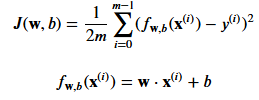  

  where, w and $x^{(i)}$ are vectors

In [76]:
def compute_cost(X,y,w,b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i],w) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = cost/(2*m)
    return cost

In [77]:
cost = compute_cost(X_train,y_train,w_init,b_init)
print(f"Cost at optimal w: {cost}")

Cost at optimal w: 1.5578904880036537e-12


## Gradient Descent with Multiple Variables  
  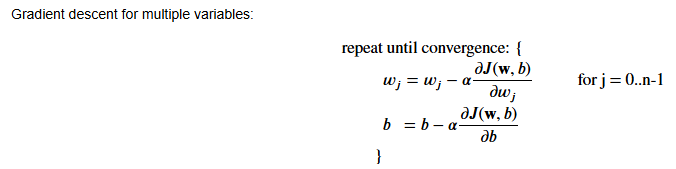

### Compute Gradient with Multiple Variables

In [78]:
def compute_gradient(X,y,w,b):
    m,n = X.shape    #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err = (np.dot(X[i],w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err*X[i,j]
        dj_db = dj_db + err
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_db, dj_dw

In [79]:
tmp_dj_dw, tmp_dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print(f"dj_db at initail w,b: {tmp_dj_db}")
print(f"dj_dw at initial w,b: {tmp_dj_dw}")

dj_db at initail w,b: [-2.72623581e-03 -6.27197272e-06 -2.21745580e-06 -6.92403399e-05]
dj_dw at initial w,b: -1.673925169143331e-06


### Gradient Descent with Multiple Variables

In [80]:
def gradient_descent(X,y,w_in,b_in, cost_function,gradient_function, alpha,num_iters):
    j_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X,y,w,b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            j_history.append(cost_function(X,y,w,b))

        if i % math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")
    
    return w, b, j_history


In [81]:
initial_w = np.zeros_like(w_init)
initial_b = 0

iterations = 1000
alpha = 5.0e-7

w_final, b_final, j_hist = gradient_descent(X_train,y_train,initial_w,initial_b, compute_cost,compute_gradient,
                                            alpha,iterations)

print(f"b, w found by gradient descent: {b_final:0.2f}, {w_final}")

# prediction
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f} target value: {y_train[i]}")

Iteration    0: Cost  2529.46
Iteration  100: Cost   695.99
Iteration  200: Cost   694.92
Iteration  300: Cost   693.86
Iteration  400: Cost   692.81
Iteration  500: Cost   691.77
Iteration  600: Cost   690.73
Iteration  700: Cost   689.71
Iteration  800: Cost   688.70
Iteration  900: Cost   687.69
b, w found by gradient descent: -0.00, [ 0.20396569  0.00374919 -0.0112487  -0.0658614 ]
prediction: 426.19 target value: 460
prediction: 286.17 target value: 232
prediction: 171.47 target value: 178


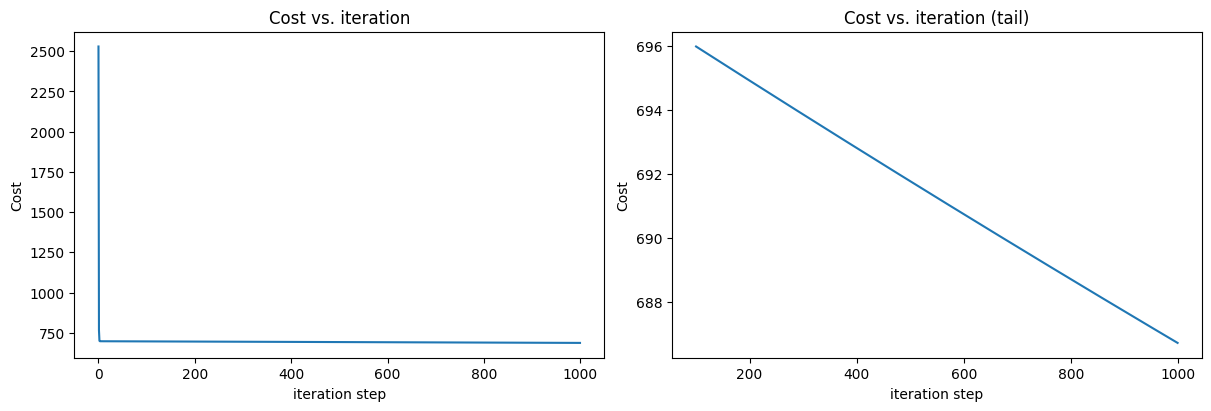

In [82]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(j_hist)
ax2.plot(100 + np.arange(len(j_hist[100:])), j_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step')
plt.show()